In [60]:
import pandas as pd
import numpy as np
import os
import re
from sklearn.model_selection import train_test_split
from sklearn.experimental import enable_hist_gradient_boosting
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import seaborn as sns
import matplotlib.pyplot as plt

In [61]:
result_df = pd.read_csv('data/fitness_aggregated_cleared.csv')
result_df.shape

(5029, 75)

### Признаки из extension & title

In [62]:
def to_find_studio(row):
    value = row['extension']
    title = row['title']
    if value:
        value = str(value).lower()
        if 'пилатес' in value or 'йога' in value or 'студия' in value or 'растяжк' in value or 'стретчинг' in value:
            return 1
    if title:
        title = str(title).lower()
        if 'пилатес' in title or 'йога' in title or 'студия' in title or 'растяжк' in title or 'стретчинг' in title or 'stretch' in title or 'shap' in title or 'pilates' in title or 'восток ' in title or 'гармон'in title:
            return 1
        
    return 0
def to_find_complex_castle(value):
    value = str(value).lower()
    if 'дворец' in value or 'дворцы' in value or 'комплекс' in value:
        return 1
    else:
        return 0
result_df['studio'] = result_df.apply(to_find_studio, axis=1)
result_df['complex_castle'] = result_df['extension'].apply(to_find_complex_castle)

### Признаки из content

In [63]:
def to_pool(values):
    if 'бассейн' in str(values).lower():
        return 1
    else:
        return 0
def to_akva(values):
    if 'аквааэробик' in str(values).lower():
        return 1
    else:
        return 0
def to_sauna(values):
    if 'саун' in str(values).lower():
        return 1
    else:
        return 0

def to_sun(values):
    if 'соляри' in str(values).lower():
        return 1
    else:
        return 0

def to_tennis(values):
    if 'теннис' in str(values).lower():
        return 1
    else:
        return 0

def to_kort(values):
    if 'корт' in str(values).lower():
        return 1
    else:
        return 0

def to_box(values):
    if 'бокс' in str(values).lower():
        return 1
    else:
        return 0
        
def to_cycle(values):
    if 'сайкл' in str(values).lower():
        return 1
    else:
        return 0

def to_stretch(values):
    if 'стретчинг' in str(values).lower():
        return 1
    else:
        return 0
        
def to_pilates(values):
    if 'пилатес' in str(values).lower():
        return 1
    else:
        return 0

def to_count_trainings(values):
    return len(str(values).split(','))

result_df['pool'] = result_df['content'].apply(to_pool)
result_df['akva'] = result_df['content'].apply(to_akva)
result_df['sauna'] = result_df['content'].apply(to_sauna)
result_df['sun'] = result_df['content'].apply(to_sun)
result_df['tennis'] = result_df['content'].apply(to_tennis)
result_df['kort'] = result_df['content'].apply(to_kort)
result_df['box'] = result_df['content'].apply(to_box)
result_df['cycle'] = result_df['content'].apply(to_cycle)
result_df['stretch'] = result_df['content'].apply(to_stretch)
result_df['pilates'] = result_df['content'].apply(to_pilates)
result_df['trainings'] = result_df['content'].apply(to_count_trainings)

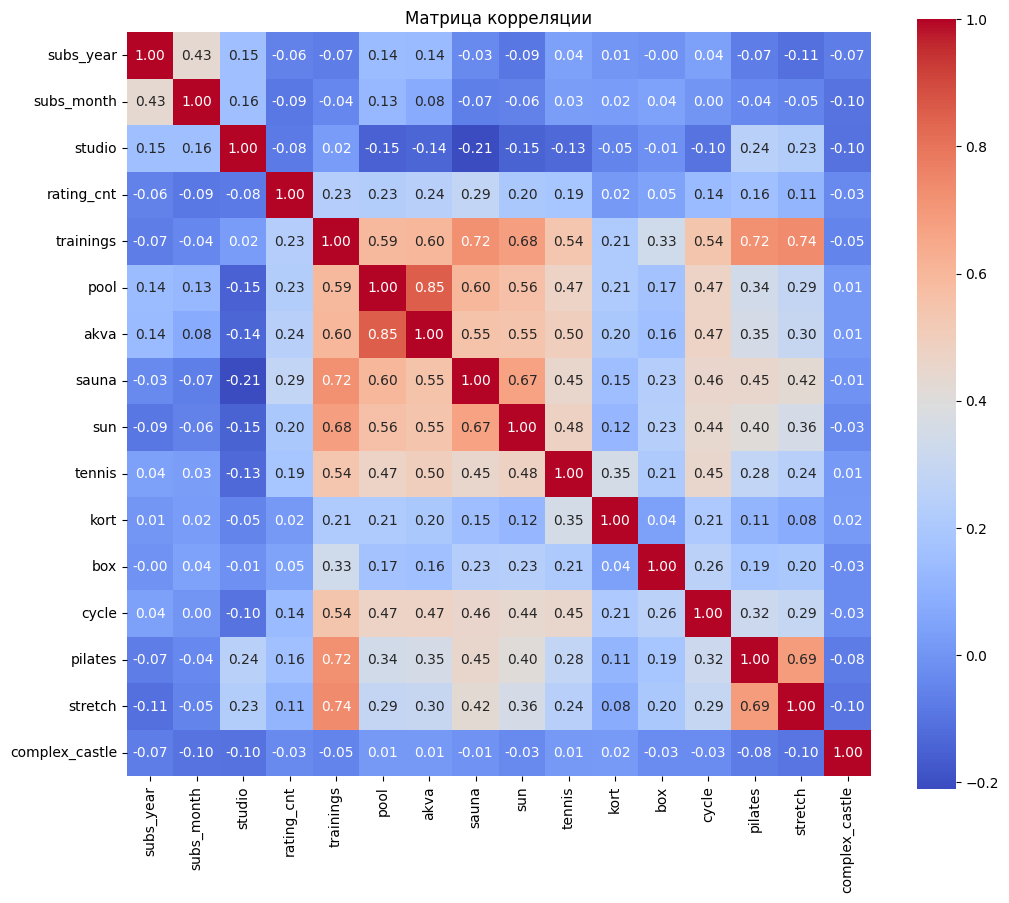

In [64]:
correlation_matrix = result_df[['subs_year',
                               'subs_month',
                               'studio',
                               'rating_cnt',
                               # 'area_building_osm',
                               # 'intersect_building_osm_known',
                               # 'competitors_count',
                               # 'own_network_count',
                               'trainings',
                               'pool',
                               'akva',
                               'sauna',
                               'sun',
                               'tennis',
                               'kort',
                               'box',
                               'cycle',
                               'pilates',
                               'stretch',
                               'complex_castle']].corr()

# Настройка графика
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True)

# Заголовок
plt.title('Матрица корреляции')
plt.show()

### Делаем предсказание

In [65]:
train_df = pd.read_excel('data/train_df.xlsx')
train_df_ = train_df.drop_duplicates(subset = ['title', 'lat', 'lon'])

features_test = ['subs_year','subs_month',
               'rating_cnt',
               'studio', 
               # 'intersect_building_osm_known', 
               # 'competitors_count',
               # 'own_network_count',
             'trainings',
              'pool',
              'akva',
              'sauna',
              'sun',
              'tennis',
              'kort',
              'box',
              'cycle',
              'pilates',
              'stretch',
              'complex_castle'
             ]

X = train_df_[features_test]

features = [
               'rating_cnt',
               'studio', 
               # 'intersect_building_osm_known', 
               # 'competitors_count',
               #'own_network_count',
               'trainings',
               'pool',
               #'subs_year','subs_month',
               #'akva',
               'sauna',
               'sun',
               'tennis',
               'cycle',
              #'pilates',
              #'stretch',
               #'kort',
               #'box',
               'complex_castle'
           ]

y = train_df_['area_1000']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_test_df = X_test.copy()
X_test_df['area_1000']=y_test.copy()
X_train = X_train[features]
X_test = X_test[features]
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


model = HistGradientBoostingClassifier(random_state=42, l2_regularization= 1,
learning_rate= 0.01, max_depth= 4, max_iter= 300, min_samples_leaf= 15, max_features = 0.3, class_weight='balanced')

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
X_test_df['class_area'] = y_pred
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy:.2f}')
print('Confusion Matrix:')
print(conf_matrix)
print('Classification Report:')
print(class_report)

Accuracy: 0.90
Confusion Matrix:
[[289  28]
 [ 20 125]]
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.91      0.92       317
           1       0.82      0.86      0.84       145

    accuracy                           0.90       462
   macro avg       0.88      0.89      0.88       462
weighted avg       0.90      0.90      0.90       462



In [66]:
# студия
X_test_df['class_area'] = np.where(X_test_df['studio'] == 1,
                                             0,
                                             X_test_df['class_area'])

# # площадь здания
# X_test_df['intersect_building_osm_known_0'] = X_test_df['intersect_building_osm_known'].fillna(1000)
# X_test_df['class_area'] = np.where(X_test_df['intersect_building_osm_known_0'] < 1000, 
#                                                0, 
#                                                X_test_df['class_area'])
# аквааэробика
X_test_df['class_area'] = np.where(X_test_df['akva'] == 1,
                                             1,
                                             X_test_df['class_area'])
# корт
X_test_df['class_area'] = np.where(X_test_df['kort'] == 1,
                                             1,
                                             X_test_df['class_area'])
# комплекс или дворец спорта
X_test_df['class_area'] = np.where(X_test_df['complex_castle'] == 1,
                                             1,
                                             X_test_df['class_area'])
# бассейн, сауна, солярий
X_test_df['class_area'] = np.where((X_test_df['pool'] == 1) & (X_test_df['sauna'] == 1) | (X_test_df['pool'] == 1) & (X_test_df['sun'] == 1) | (X_test_df['pool'] == 1) & (X_test_df['cycle'] == 1), 
                                               1, 
                                               X_test_df['class_area'])

In [67]:
# Оценка модели
y_pred = X_test_df['class_area']
y_val = X_test_df['area_1000']
accuracy = accuracy_score(y_val, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

# Вывод результатов
print(f'Accuracy: {accuracy:.2f}')
print('Confusion Matrix:')
print(conf_matrix)
print('Classification Report:')
print(classification_report(y_val, y_pred))

Accuracy: 0.90
Confusion Matrix:
[[289  28]
 [ 18 127]]
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.91      0.93       317
           1       0.82      0.88      0.85       145

    accuracy                           0.90       462
   macro avg       0.88      0.89      0.89       462
weighted avg       0.90      0.90      0.90       462



### Делаем предсказание

In [68]:
X_cities = result_df[features].copy()
X_cities_df = result_df[features_test].copy()
X_cities = scaler.transform(X_cities)
y_pred = model.predict(X_cities)
X_cities_df.loc[:, 'class_area'] = y_pred

In [69]:
X_cities_df['class_area'].value_counts()

class_area
0    4203
1     826
Name: count, dtype: int64

In [70]:
# студия
X_cities_df['class_area'] = np.where(X_cities_df['studio'] == 1,
                                             0,
                                             X_cities_df['class_area'])

# # площадь здания
# X_cities_df['intersect_building_osm_known_0'] = X_cities_df['intersect_building_osm_known'].fillna(1000)
# X_cities_df['class_area'] = np.where(X_cities_df['intersect_building_osm_known_0'] < 1000, 
#                                                0, 
#                                                X_cities_df['class_area'])

# аквааэробика
X_cities_df['class_area'] = np.where(X_cities_df['akva'] == 1,
                                             1,
                                             X_cities_df['class_area'])

# корт
X_cities_df['class_area'] = np.where(X_cities_df['kort'] == 1,
                                             1,
                                             X_cities_df['class_area'])

# комплекс или дворец спорта
X_cities_df['class_area'] = np.where(X_cities_df['complex_castle'] == 1,
                                             1,
                                             X_cities_df['class_area'])

# бассейн, сауна, солярий
X_cities_df['class_area'] = np.where((X_cities_df['pool'] == 1) & (X_cities_df['sauna'] == 1) | (X_cities_df['pool'] == 1) & (X_cities_df['sun'] == 1) | (X_cities_df['pool'] == 1) & (X_cities_df['cycle'] == 1), 
                                               1, 
                                               X_cities_df['class_area'])


In [71]:
X_cities_df['class_area'].value_counts()

class_area
0    4188
1     841
Name: count, dtype: int64

In [72]:
X_cities_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5029 entries, 0 to 5028
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   subs_year       655 non-null    float64
 1   subs_month      1590 non-null   float64
 2   rating_cnt      2665 non-null   float64
 3   studio          5029 non-null   int64  
 4   trainings       5029 non-null   int64  
 5   pool            5029 non-null   int64  
 6   akva            5029 non-null   int64  
 7   sauna           5029 non-null   int64  
 8   sun             5029 non-null   int64  
 9   tennis          5029 non-null   int64  
 10  kort            5029 non-null   int64  
 11  box             5029 non-null   int64  
 12  cycle           5029 non-null   int64  
 13  pilates         5029 non-null   int64  
 14  stretch         5029 non-null   int64  
 15  complex_castle  5029 non-null   int64  
 16  class_area      5029 non-null   int64  
dtypes: float64(3), int64(14)
memory u

In [73]:
result_df.loc[:, 'class_area'] = X_cities_df['class_area']
result_df['class_area']=result_df.apply(lambda row: 1 if row['clean_title']=='ddxfitness' or row['clean_title']=='worldclass' else row['class_area'], axis=1)

In [74]:
result_df[result_df['class_area']==1]['clean_title'].value_counts()

clean_title
ddxfitness         65
worldclass         49
мосспортобъект     37
spiritfitness      26
xfit               25
                   ..
befitt              1
bazafitnessclub     1
bargym              1
baraccudacoach      1
aurora              1
Name: count, Length: 462, dtype: int64

In [75]:
result_df['class_area'].value_counts()

class_area
0    4173
1     856
Name: count, dtype: int64

In [76]:
result_df.to_csv('fitness_features_with_areaclass.csv', index=False)

In [77]:
result_df.shape

(5029, 89)